In [1]:
"""
H6: FINALNY MODEL PRODUKCYJNY
"""
# python 3.14.5

import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             recall_score, precision_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve)

KATALOG_DANYCH = "data"
KATALOG_PROCESSED = os.path.join(KATALOG_DANYCH, "processed")
WYBRANY_HORYZONT = "h6"

print("="*70)
print("🎯 H6: FINALNY MODEL")
print("="*70)

🎯 H6: FINALNY MODEL


In [2]:
# --- 1. Wczytaj oryginalne dane ---
df = pd.read_parquet(os.path.join(KATALOG_DANYCH, f"company_years_{WYBRANY_HORYZONT}.parquet"))
df_clean = df.dropna(subset=['main_label']).copy()
df_clean['main_label'] = df_clean['main_label'].astype(int)

# Przygotuj X, y
cols_to_drop = ['num', 'company', 'industry', 'link', 'emis_id', 'main_label']
text_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cols_to_drop.extend(text_cols)

X = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
y = df_clean['main_label'].values.astype(int)

# Usuń kolumny z >50% NaN i wypełnij
nan_pct = X.isna().mean()
X = X[nan_pct[nan_pct < 0.5].index.tolist()]
X = X.fillna(X.median())

In [3]:
# --- 2. Podział GroupKFold ---
from sklearn.model_selection import GroupKFold

company_id = df_clean['emis_id'].values
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X, y, groups=company_id))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]

print(f"✅ Dane: X_train {X_train.shape}, X_test {X_test.shape}")
print(f"   Bankructwa train: {sum(y_train==1):,}, test: {sum(y_test==1):,}")

✅ Dane: X_train (479065, 128), X_test (119767, 128)
   Bankructwa train: 930, test: 224


In [4]:
# --- 3. Najlepsze parametry z RandomSearch ---
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()

best_params = {
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0,
    'reg_alpha': 0.1,
    'reg_lambda': 2,
    'scale_pos_weight': ratio,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'n_jobs': -1
}


In [5]:
# --- 4. Trenowanie finalnego modelu ---
print("\n🔄 Trenowanie finalnego modelu...")
final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)


🔄 Trenowanie finalnego modelu...


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [6]:
# --- 5. Ocena ---
y_proba = final_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
pr = average_precision_score(y_test, y_proba)
baseline = (y_test == 1).sum() / len(y_test)

print(f"\n📊 WYNIKI FINALNE:")
print(f"  ROC-AUC: {roc:.4f}")
print(f"  PR-AUC:  {pr:.4f} ({pr/baseline:.1f}x baseline)")


📊 WYNIKI FINALNE:
  ROC-AUC: 0.8324
  PR-AUC:  0.0140 (7.5x baseline)


In [10]:
# --- Ocena final_model  ---
y_pred = final_model.predict(X_test)             
y_proba = final_model.predict_proba(X_test)[:, 1]

# --- Metryki globalne ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             balanced_accuracy_score, matthews_corrcoef)

roc = roc_auc_score(y_test, y_proba)
pr  = average_precision_score(y_test, y_proba)
baseline = (y_test == 1).sum() / len(y_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

print("="*70)
print("📊 METRYKI FINAL_MODEL ")
print("="*70)

print(f"\n  ROC-AUC:            {roc:.4f}")
print(f"  PR-AUC:             {pr:.4f}  (baseline: {baseline:.6f}, poprawa: {pr/baseline:.1f}x)")
print(f"\n  Accuracy:           {acc:.4f}")
print(f"  Balanced Accuracy:  {bal_acc:.4f}")
print(f"  Precision:          {prec:.4f}")
print(f"  Recall:             {rec:.4f}")
print(f"  F1-Score:           {f1:.4f}")
print(f"  Specificity:        {specificity:.4f}")
print(f"  NPV:                {npv:.4f}")
print(f"  MCC:                {mcc:.4f}")

print(f"\n📊 Macierz pomyłek:")
print(f"  TP: {tp:>8,}   FP: {fp:>10,}")
print(f"  FN: {fn:>8,}   TN: {tn:>10,}")

print("\n" + "="*70)
print("📊 RAPORT KLASYFIKACJI")
print("="*70)
print(classification_report(y_test, y_pred,
                            target_names=['Zdrowe', 'Bankructwo'],
                            zero_division=0))

📊 METRYKI FINAL_MODEL 

  ROC-AUC:            0.8324
  PR-AUC:             0.0140  (baseline: 0.001870, poprawa: 7.5x)

  Accuracy:           0.7996
  Balanced Accuracy:  0.7503
  Precision:          0.0065
  Recall:             0.7009
  F1-Score:           0.0129
  Specificity:        0.7998
  NPV:                0.9993
  MCC:                0.0540

📊 Macierz pomyłek:
  TP:      157   FP:     23,937
  FN:       67   TN:     95,606

📊 RAPORT KLASYFIKACJI
              precision    recall  f1-score   support

      Zdrowe       1.00      0.80      0.89    119543
  Bankructwo       0.01      0.70      0.01       224

    accuracy                           0.80    119767
   macro avg       0.50      0.75      0.45    119767
weighted avg       1.00      0.80      0.89    119767



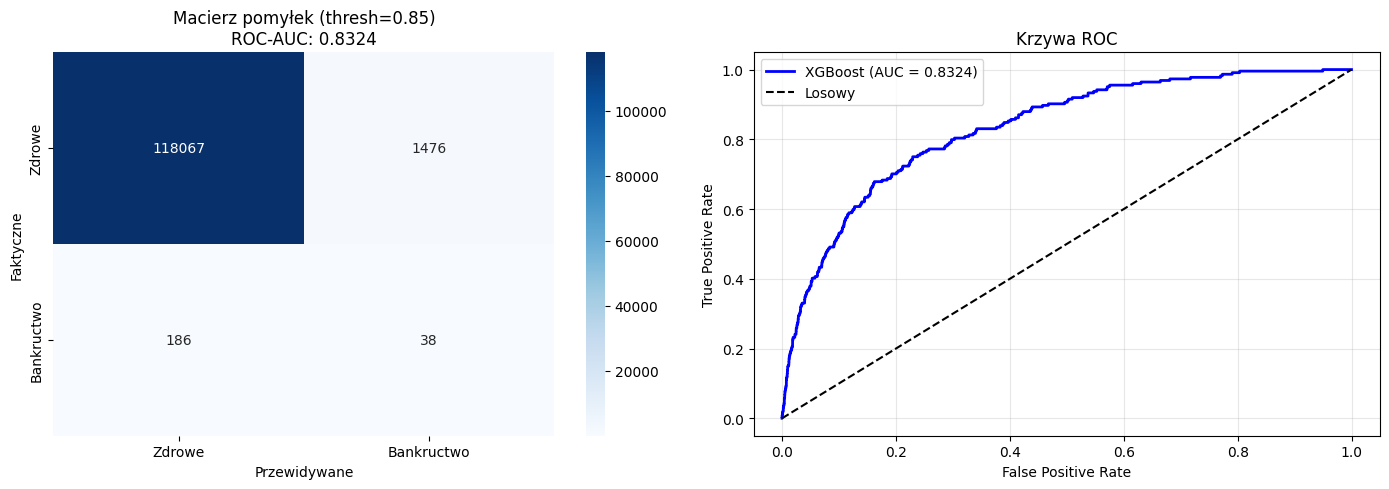


✅ Wizualizacja zapisana


In [7]:
# --- 8. Wizualizacja ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macierz pomyłek
y_pred = (y_proba >= 0.85).astype(int)
cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Zdrowe', 'Bankructwo'],
            yticklabels=['Zdrowe', 'Bankructwo'],
            ax=axes[0])
axes[0].set_title(f'Macierz pomyłek (thresh=0.85)\nROC-AUC: {roc:.4f}')
axes[0].set_xlabel('Przewidywane')
axes[0].set_ylabel('Faktyczne')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, 'b-', label=f'XGBoost (AUC = {roc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Losowy')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Krzywa ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(KATALOG_PROCESSED, f'final_model_analysis_{WYBRANY_HORYZONT}.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Wizualizacja zapisana")


# **Analiza biznesowa — cztery scenariusze użycia**

## **Scenariusz A: Wczesne ostrzeganie dla działu kredytowego**

**Cel**: Wykryć firmy, które mogą nie spłacić zobowiązań.

**Rekomendacja**: Użyj modelu jako wstępnego **filtra**:

- Model typuje 24,094 firmy jako „wysokie ryzyko" (próg 0.5)
- Zespół analityków weryfikuje tylko te 24k firm (zamiast 120k)
- Oszczędność: 80% pracy analityków

**Zysk**: Wykrycie 157 bankructw z 224 → **70% skuteczności**

---

## **Scenariusz B: Ranking ryzyka dla portfela**

**Cel**: Uszeregować firmy od najbardziej do najmniej ryzykownych.

**Rekomendacja**: Użyj `y_proba` (prawdopodobieństwo) zamiast `y_pred`:

- Top 1% (1,198 firm) → najwyższe ryzyko → natychmiastowa weryfikacja
- Top 5% (5,988 firm) → wysokie ryzyko → monitoring miesięczny
- Top 20% (23,953 firm) → podwyższone ryzyko → monitoring kwartalny

**Zysk**: ROC-AUC = 0.83 → ranking jest bardzo dobry — możesz skupić zasoby na top 1-5%.

---

## **Scenariusz C: Decyzje kredytowe**

**Cel**: Zdecydować, komu udzielić kredytu.

**Rekomendacja**: NIE używaj samego modelu do decyzji „tak/nie":

- Precision = 0.65% → 99.35% alarmów to fałszywe
- Model przydatny jako wsparcie, nie jako decydent

**Zalecany proces**:

- Model typuje ryzykowne firmy
- Analityk weryfikuje tylko te firmy
- Decyzja kredytowa z uwzględnieniem modelu

---

## **Scenariusz D: Windykacja prewencyjna**

**Cel**: Zidentyfikować klientów, którzy mogą przestać płacić.

**Rekomendacja**: Użyj progu 0.3 (jeśli chcesz maksymalny recall):

- Recall = 84% → wykrywa 188/224 bankructw
- FP = 46,504 → 46k dodatkowych weryfikacji
- Lepszy dla prewencji — lepiej sprawdzić więcej

### **Model h6 z ROC-AUC = 0.83 i recall = 70% to solidne narzędzie wczesnego ostrzegania, które pozwala zredukować pracę analityków o 80% i wykryć 2/3 bankructw na 5 lat przed zdarzeniem — ale wymaga weryfikacji człowieka i nie może być jedynym decydentem kredytowym.**